# Nowcasting en tiempo real y atribución de noticias de Bańbura-Modugno en América Latina: datos escalonados, descomposición de revisiones y calibración de densidad

**¿Cómo puede un equipo de banco central estimar en tiempo real un índice de actividad a partir de un panel mensual con datos escalonados, explicar cada actualización del nowcast publicación por publicación con la descomposición de noticias de Bańbura & Modugno (2014), reproducir el nowcast exactamente como se veía en una fecha anterior y calificar pronósticos de densidad con pruebas de la transformada integral de probabilidad (PIT)?**

**El panel de este cuaderno es simulado. No extraiga de él ningún hecho sobre México ni Brasil.** Cada valor se genera en la primera celda de código a partir de la semilla `np.random.default_rng(42)`: cada país tiene su propio factor de caminata aleatoria, y cada indicador es un múltiplo ruidoso de ese factor. Los nombres de los proveedores y los identificadores de las series son etiquetas tomadas del catálogo de `puremacro.fetch.realtime` (que marca varios identificadores como no verificados), y los valores simulados ignoran la frecuencia y las unidades verdaderas de esas series: la serie `433` de Brasil, por ejemplo, es una variación porcentual mensual, no un índice. El calendario de publicación es estilizado. El cartucho portátil `.pmz` registra `SIMULATED` en sus notas de procedencia. No se descarga nada, así que el cuaderno también corre en el navegador.

Los bancos centrales no pueden esperar a las cuentas nacionales, que llegan semanas después del cierre del mes o del trimestre, así que siguen indicadores mensuales que se publican con calendarios distintos. En un día cualquiera los meses más recientes del panel están incompletos: un "borde irregular". Los modelos de factores dinámicos (Giannone, Reichlin & Small 2008; Doz, Giannone & Reichlin 2011) llenan ese borde con el suavizador de Kalman. Cuando llegan datos nuevos, el nowcast se mueve, y la descomposición de Bańbura & Modugno (2014) atribuye el movimiento a la sorpresa de cada publicación y a las revisiones de datos anteriores, con una identidad contable exacta. Los pronósticos de densidad se califican con pruebas PIT (Berkowitz 2001).

## El método en matemáticas — Factores dinámicos, descomposición de noticias y calibración de densidad

**1. Modelo de factores dinámicos en espacio de estados.** Sea $X_t = [x_{1, t}, \dots, x_{n, t}]^\top$ el vector de $n$ indicadores mensuales, cada uno estandarizado con su media muestral y su desviación estándar $s_j$. Comparten $r$ factores latentes $F_t \in \mathbb{R}^r$ más errores idiosincrásicos $\xi_t$:
$$ X_t = \Lambda F_t + \xi_t, \quad \xi_t \sim \text{i.i.d.} \, \mathcal{N}(0, R), \quad R = \operatorname{diag}(\sigma_1^2, \dots, \sigma_n^2). $$
Los factores siguen un vector autorregresivo de orden $p$:
$$ F_t = A_1 F_{t-1} + \dots + A_p F_{t-p} + u_t, \quad u_t \sim \text{i.i.d.} \, \mathcal{N}(0, Q). $$
Los parámetros $(\Lambda, A, Q, R)$ se estiman en dos etapas, componentes principales y después el filtro y el suavizador de Kalman, como en Doz, Giannone y Reichlin (2011). El nowcast de la variable objetivo $y_{t^*}$ es $\hat{y}_{t^*|v} = \mathbb{E}[y_{t^*} \mid \Omega_v]$, el valor suavizado por Kalman dado el conjunto de información $\Omega_v$ de la edición $v$. Aquí el objetivo es el índice `gdp` del último mes de referencia, que ninguna de las dos ediciones ha publicado todavía.

**2. Atribución de noticias de Bańbura & Modugno (2014).** Sean $\Omega_{v-1} \subset \Omega_v$ los conjuntos de información de dos ediciones sucesivas. La información nueva consiste en publicaciones de periodos recientes $j \in \mathcal{I}_{\text{new}}$ y revisiones de observaciones anteriores $k \in \mathcal{I}_{\text{rev}}$:
$$ I_{j, v} \equiv x_{j, t_j} - \mathbb{E}[x_{j, t_j} \mid \Omega_{v-1}], \quad R_{k, v} \equiv x_{k, t_k}^{(v)} - x_{k, t_k}^{(v-1)}. $$
Con los parámetros del modelo fijos en sus estimaciones sobre $\Omega_v$, el cambio del nowcast $\Delta \hat{y}_{t^*|v} \equiv \hat{y}_{t^*|v} - \hat{y}_{t^*|v-1}$ se descompone en
$$ \Delta \hat{y}_{t^*|v} = \sum_{j \in \mathcal{I}_{\text{new}}} \omega_j \cdot I_{j, v} + \sum_{k \in \mathcal{I}_{\text{rev}}} \omega_k \cdot R_{k, v}, $$
con ponderaciones dadas por la ganancia de Kalman y las covarianzas del estado:
$$ \omega = \operatorname{Cov}\left(y_{t^*}, \begin{bmatrix} I_v \\ R_v \end{bmatrix} \mid \Omega_{v-1}\right) \left[\operatorname{Var}\left(\begin{bmatrix} I_v \\ R_v \end{bmatrix} \mid \Omega_{v-1}\right)\right]^{-1}. $$
La descomposición es exacta por construcción, así que su error reportado,
$$ \text{Error de Descomposición} \equiv \left| \Delta \hat{y}_{t^*|v} - \left(\sum \text{Impacto}_{\text{publicaciones}} + \sum \text{Impacto}_{\text{revisiones}}\right) \right|, $$
debe ser del orden del error de redondeo. Es una verificación de consistencia interna, no evidencia de que el nowcast sea preciso.

**3. Un gráfico de abanico basado en el modelo.** Con la varianza del estado $P_{T|T}$ en el último mes $T$ del panel, la varianza del estado a $h$ meses y la varianza predictiva del indicador $j$ son
$$ P_{T+h|T} = A P_{T+h-1|T} A^\top + Q, \qquad \operatorname{Var}(x_{j,T+h} \mid \Omega_v) = s_j^2 \left(\lambda_j^\top P_{T+h|T} \lambda_j + R_{jj}\right). $$
Las bandas del abanico son cuantiles gaussianos de estas varianzas; `RealtimeNowcastResult.fan_chart` las calcula con el modelo estimado, a partir del primer mes no publicado del objetivo. Ignoran la incertidumbre de los parámetros, así que son demasiado estrechas si el modelo se estima con una muestra corta.

**4. Pruebas PIT de pronósticos de densidad (Berkowitz 2001).** Para resultados $\{y_t\}_{t=1}^T$ y densidades predictivas $\mathcal{N}(\mu_t, \sigma_t^2)$, la PIT es
$$ p_t = \Phi\left(\frac{y_t - \mu_t}{\sigma_t}\right), \quad z_t = \Phi^{-1}(p_t). $$
Si las densidades son correctas, $p_t \sim \text{i.i.d.} \, \mathcal{U}(0, 1)$ y $z_t \sim \text{i.i.d.} \, \mathcal{N}(0, 1)$. Berkowitz ajusta
$$ (z_t - \mu) = \rho (z_{t-1} - \mu) + \varepsilon_t, \quad \varepsilon_t \sim \text{i.i.d.} \, \mathcal{N}(0, \sigma_\varepsilon^2), $$
y prueba $H_0: \mu = 0, \sigma_\varepsilon^2 = 1, \rho = 0$ con
$$ \text{LR} = -2 \left[ \ln L(0, 1, 0) - \ln L(\hat{\mu}, \hat{\sigma}_\varepsilon^2, \hat{\rho}) \right] \sim \chi^2(3). $$
`pit_uniformity_test` también reporta la prueba de Kolmogorov-Smirnov (KS) de uniformidad de $p_t$, que solo mira la distribución marginal de las PIT.

## Intuición

**Intuición.** Los comités de política se reúnen con un calendario fijo, estén o no publicadas las cuentas nacionales. Los indicadores mensuales llegan antes, pero cada uno cubre solo una parte de la economía y cada uno tiene su propio rezago de publicación, así que los últimos meses del panel están incompletos de maneras distintas para distintas series.

Un modelo de factores dinámicos supone que unas pocas fuerzas comunes mueven a todos los indicadores. El suavizador de Kalman estima esas fuerzas con lo que se haya publicado y completa los valores faltantes, incluido el objetivo. Cuando sale una cifra nueva, lo que mueve el nowcast no es la cifra en sí sino su *sorpresa*: la diferencia entre el valor publicado y lo que el modelo esperaba con el conjunto de información anterior. Una publicación fuerte que el modelo ya esperaba no cambia nada; una publicación débil que se esperaba fuerte reduce el nowcast.

La descomposición de Bańbura-Modugno convierte cada actualización en una cuenta: el cambio del nowcast es igual a la suma de la sorpresa de cada publicación por su ponderación, más el efecto de las revisiones de datos anteriores. Así el equipo puede decir qué publicación movió el nowcast y cuánto.

Un nowcast solo sirve si se sabe qué conjunto de información lo produjo. Reproducir el nowcast "a la fecha" de un día anterior debe usar solo los datos publicados hasta entonces; de lo contrario la reproducción parece mejor de lo que el nowcast en tiempo real fue nunca. Por último, un pronóstico de densidad es honesto solo si sus bandas no son ni demasiado estrechas ni demasiado anchas. Las pruebas PIT pueden detectar esos errores, pero solo con suficientes pronósticos; la celda de Tu turno mide con qué frecuencia lo logran.

In [1]:
# Preamble: numerical libraries, plotting style, and realtime nowcast modules
import sys
from pathlib import Path
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.fetch.realtime import (
    VintagePanel,
    pack_realtime_cartridge,
    load_realtime_cartridge,
)
from puremacro.nowcast import (
    realtime_nowcast,
    pit_uniformity_test,
)

# Deterministic random seed: every value below is simulated
rng = np.random.default_rng(42)

In [2]:
# --- Experiment 1: a simulated two-country vintage panel with a publication calendar ---
# ALL VALUES BELOW ARE SIMULATED from seed 42. The provider names and series IDs are labels
# borrowed from puremacro.fetch.realtime's catalogue; the simulated values ignore those
# series' true frequencies and units.
dates = pd.date_range("2022-01-01", periods=36, freq="MS")   # reference months 2022-01 to 2024-12
v1 = pd.Timestamp("2025-01-15")                               # vintage v-1
v2 = pd.Timestamp("2025-02-15")                               # vintage v
# Stylised publication lags in months: a vintage dated in month m holds data up to month m - 1 - lag
pub_lag = {"gdp": 2, "activity": 1, "ip": 1, "cpi": 0, "policy_rate": 0}
revised_month, revision_size = 20, 0.45                       # vintage v revises 'activity' for 2023-09

mex_series = [
    ("gdp", "inegi", "735848", "index"),
    ("activity", "inegi", "736184", "index"),
    ("ip", "inegi", "736184_IP", "index"),
    ("cpi", "inegi", "628197", "index"),
    ("policy_rate", "banxico", "SF61745", "rate"),
]

bra_series = [
    ("gdp", "bcb", "22099", "index"),
    ("activity", "bcb", "24363", "index"),
    ("ip", "bcb", "21859", "index"),
    ("cpi", "bcb", "433", "index"),
    ("policy_rate", "bcb", "432", "rate"),
]

rows = []
for country, series_list in [("MEX", mex_series), ("BRA", bra_series)]:
    # Each country has its own random-walk common factor
    f_latent = np.cumsum(rng.normal(scale=0.25, size=len(dates)))
    for var, prov, sid, un in series_list:
        load = rng.uniform(0.7, 1.3)
        noise = rng.normal(scale=0.15, size=len(dates))
        y_sim = 100.0 + 1.5 * f_latent * load + noise if un == "index" else 8.0 - 0.1 * f_latent * load + noise

        for vint in (v1, v2):
            last_month = (vint.to_period("M") - 1 - pub_lag[var]).to_timestamp()
            for t_idx, d in enumerate(dates):
                if d > last_month:
                    continue  # not yet published in this vintage: the ragged edge
                val = float(y_sim[t_idx])
                if vint == v2 and var == "activity" and t_idx == revised_month:
                    val += revision_size  # the agency revises an old month
                rows.append({
                    "country": country, "variable": var, "date": d, "vintage": vint,
                    "value": val, "provider": prov, "series_id": sid, "units": un,
                })

df_panel = pd.DataFrame(rows)
panel_raw = VintagePanel(df_panel)

# Package into a self-verifying .pmz cartridge and reload it
with tempfile.TemporaryDirectory() as td:
    cart_path = Path(td) / "latam_realtime_nowcast.pmz"
    pack_realtime_cartridge(
        panel_raw,
        cart_path,
        source="Banxico, INEGI, BCB (identifiers only)",
        notes="SIMULATED panel on identifiers borrowed from the puremacro.fetch.realtime catalogue",
    )
    loaded_panel = load_realtime_cartridge(cart_path)

calendar = (df_panel[df_panel["country"] == "MEX"].groupby(["variable", "vintage"])["date"].max()
            .dt.strftime("%Y-%m").unstack("vintage"))
calendar.columns = [f"published by {c:%Y-%m-%d}" for c in calendar.columns]

print("Simulated vintage panel (identifiers borrowed, values simulated):")
print(f"  Observations      : {len(panel_raw):,}")
print(f"  Countries         : {panel_raw.countries}")
print(f"  Variables         : {panel_raw.variables}")
print(f"  Reference months  : {dates[0]:%Y-%m} to {dates[-1]:%Y-%m}")
print(f"  Vintages          : {v1:%Y-%m-%d} (v-1) and {v2:%Y-%m-%d} (v)")
print("\nLast reference month published, Mexico:")
print(calendar.to_string())

assert panel_raw.countries == ["BRA", "MEX"]
assert len(loaded_panel) == len(panel_raw)
assert (df_panel["date"] < df_panel["vintage"]).all(), "no vintage may hold data for months after its own date"
assert not ((df_panel["variable"] == "gdp") & (df_panel["date"] == dates[-1])).any(), "the target month is unpublished"

Simulated vintage panel (identifiers borrowed, values simulated):
  Observations      : 710
  Countries         : ['BRA', 'MEX']
  Variables         : ['activity', 'cpi', 'gdp', 'ip', 'policy_rate']
  Reference months  : 2022-01 to 2024-12
  Vintages          : 2025-01-15 (v-1) and 2025-02-15 (v)

Last reference month published, Mexico:
            published by 2025-01-15 published by 2025-02-15
variable                                                   
activity                    2024-11                 2024-12
cpi                         2024-12                 2024-12
gdp                         2024-10                 2024-11
ip                          2024-11                 2024-12
policy_rate                 2024-12                 2024-12


In [3]:
# --- Experiment 2: nowcasts, news attribution and a historical replay ---
target_month = dates[-1]
res_mex = realtime_nowcast(country="MEX", panel=loaded_panel, method="dfm", n_factors=1)
res_bra = realtime_nowcast(country="BRA", panel=loaded_panel, method="dfm", n_factors=1)

# Replay: what the same call returned on v-1, and the same call on a panel cut at v-1
res_mex_v1 = realtime_nowcast(country="MEX", panel=loaded_panel, method="dfm", n_factors=1, as_of=v1)
res_mex_cut = realtime_nowcast(country="MEX", panel=VintagePanel(df_panel[df_panel["vintage"] <= v1]),
                               method="dfm", n_factors=1)
nd_mex = res_mex.news_decomposition
nd_bra = res_bra.news_decomposition

print(res_mex.summary())
print("\nNews by release (Mexico):")
print(nd_mex.news_table.to_string(index=False, float_format="{:.4f}".format))
print("\nRevisions (Mexico):")
print(nd_mex.revision_table.to_string(index=False, float_format="{:.4f}".format))
print("\n" + "=" * 74)
print(f"Brazil nowcast for {target_month:%Y-%m}: {res_bra.nowcast:.4f} (s.d. {res_bra.forecast_sd:.4f}); "
      f"revision {nd_bra.revision:+.4f}, decomposition error {nd_bra.decomposition_error:.1e}")
print("=" * 74)
print(f"Replay as of {v1:%Y-%m-%d}: nowcast {res_mex_v1.nowcast:.4f} (s.d. {res_mex_v1.forecast_sd:.4f}), "
      f"news decomposition: {res_mex_v1.news_decomposition}")
print(f"Same call on the panel cut at {v1:%Y-%m-%d}: nowcast {res_mex_cut.nowcast:.4f}")
print(f"Previous nowcast inside the news decomposition (v-1 data, parameters estimated on v): {nd_mex.forecast_old:.4f}")
print(f"Effect of re-estimating the parameters: {nd_mex.forecast_old - res_mex_v1.nowcast:+.4f}")

# Internal checks: the identity, the target, and the information set of the replay
assert res_mex.target_period == target_month and res_mex.previous_vintage == v1
assert nd_mex.decomposition_error < 1e-10 and nd_bra.decomposition_error < 1e-10
assert abs(nd_mex.forecast_new - res_mex.nowcast) < 1e-10, "an unpublished target: the nowcast is the model's value"
assert res_mex_v1.news_decomposition is None, "no vintage precedes v-1"
assert abs(res_mex_v1.nowcast - res_mex_cut.nowcast) < 1e-12, "a replay may use only data published by as_of"
assert res_mex.forecast_sd < res_mex_v1.forecast_sd, "in this example the extra month of data narrows the band"

Real-Time Macroeconomic Nowcast: Mexico (MEX)
Institutional Source: Banco de México (Banxico) / INEGI
Target Variable               : gdp
Target Reference Period       : 2024-12-01 00:00:00
Estimation Engine             : DFM
Latest Information Vintage    : 2025-02-15 00:00:00
--------------------------------------------------------------------------
Point Nowcast                 : +100.6233
Forecast Std. Error (1-sigma) : 0.1108
68% Confidence Interval       : [+100.5125, +100.7342]
90% Confidence Interval       : [+100.4411, +100.8056]
--------------------------------------------------------------------------
Latest Vintage News & Revisions Attribution:
  Baseline Vintage (v-1)      : 2025-01-15 00:00:00
  Previous Nowcast (v-1)      : +100.7341
  Updated Nowcast (v)         : +100.6233
  Total Nowcast Revision (Δy) : -0.1108
  Impact from new releases    : -0.1108
  Impact from revisions       : +0.0000
  Analytical Identity Error   : 1.05e-15 (< 1e-10)
-----------------------------

In [4]:
# --- Experiment 3a: PIT tests on a forecaster that is calibrated by construction ---
# These 60 forecasts are NOT the DFM's. The means and standard deviations are drawn at random
# and each outcome is drawn from the forecaster's own density, so the null of the tests is true.
# The experiment shows what the tests report in that case; it says nothing about the nowcasts above.
T_eval = 60
mu_eval = rng.normal(loc=2.0, scale=0.5, size=T_eval)
sd_eval = rng.uniform(0.4, 0.8, size=T_eval)
y_eval = mu_eval + sd_eval * rng.normal(size=T_eval)

pit_res = pit_uniformity_test(realised=y_eval, mu=mu_eval, sigma=sd_eval)
print(pit_res.summary())
assert 0.0 <= pit_res.lr_pvalue <= 1.0 and 0.0 <= pit_res.ks_pvalue <= 1.0

# --- Experiment 3b: a model-based fan chart for Mexico's gdp index ---
# res_mex.fan_chart builds the fan from the fitted DFM's state space (section 3 of the math):
# the unpublished months left in the panel, then 3 months beyond it; the history is published data.
fc_mex = res_mex.fan_chart(horizon=3, levels=(0.3, 0.6, 0.9), palette=_nbstyle.S2["color"])
fc_mean = fc_mex.forecast_mean
fc_sd = (fc_mex.intervals[0.9][1] - fc_mean) / norm.ppf(0.95)
gdp_hist = fc_mex.history

fan_table = pd.DataFrame({"mean": fc_mean, "s.d.": fc_sd,
                          "90% low": fc_mex.intervals[0.9][0], "90% high": fc_mex.intervals[0.9][1]})
fan_table.index = pd.DatetimeIndex(fan_table.index).strftime("%Y-%m")
print(f"\nMexico gdp index, one-factor DFM (last published month {gdp_hist.index[-1]:%Y-%m}, value {gdp_hist.iloc[-1]:.4f}):")
print(fan_table.round(4).to_string())

# Independent check of the library against the formula in section 3, from the same fitted matrices
fit = res_mex.model_result
j = list(fit.columns).index("gdp")
lam = np.zeros(fit.A.shape[0])
lam[: fit.n_factors] = fit.loadings[j]
P = np.asarray(fit.smoother_out["P_smooth"])[-1]   # state variance in the last month of the panel
hand_sd = []
for h in range(4):
    if h > 0:
        P = fit.A @ P @ fit.A.T + fit.Q             # one month further ahead
    hand_sd.append(float(fit.stds[j] * np.sqrt(lam @ P @ lam + fit.H[j, j])))

assert fc_mean.index[0] == target_month, "the fan starts at the first unpublished gdp month"
assert abs(fc_mean.iloc[0] - res_mex.nowcast) < 1e-10 and abs(fc_sd.iloc[0] - res_mex.forecast_sd) < 1e-10
assert np.allclose(fc_sd.to_numpy(), hand_sd, atol=1e-10), "library fan = formula in section 3"
assert np.allclose(fc_mean.to_numpy()[1:], fit.predict(steps=3)["gdp"].to_numpy(), atol=1e-10)
assert np.all(np.diff(fc_sd.to_numpy()) > 0), "the fan must widen with the horizon"
assert gdp_hist.equals(loaded_panel.as_of(v2).xs("MEX")["gdp"].dropna().iloc[-12:]), "history = published data"

Probability Integral Transform (PIT) Calibration Evaluation
Observations evaluated (T)     : 60
Verdict                        : Cannot reject uniformity or independence of the PITs at 5%
------------------------------------------------------------------------
Berkowitz (2001) Likelihood Ratio Test [H0: z ~ i.i.d. N(0, 1)]:
  LR test statistic            : 2.8021
  Degrees of freedom           : 3
  p-value                      : 0.4232 (Fail to reject H0)
  Estimated AR(1) parameters   : μ = -0.1253, σ = 0.9656, ρ = -0.1779
------------------------------------------------------------------------
Kolmogorov-Smirnov Goodness-of-Fit Test [H0: PIT ~ U(0, 1)]:
  KS test statistic            : 0.1015
  p-value                      : 0.5327 (Fail to reject H0)
------------------------------------------------------------------------
Point estimates (descriptive; the LR test above is the joint test):
  • Neither test rejects. This is a failure to reject, not evidence of
    calibration: with T

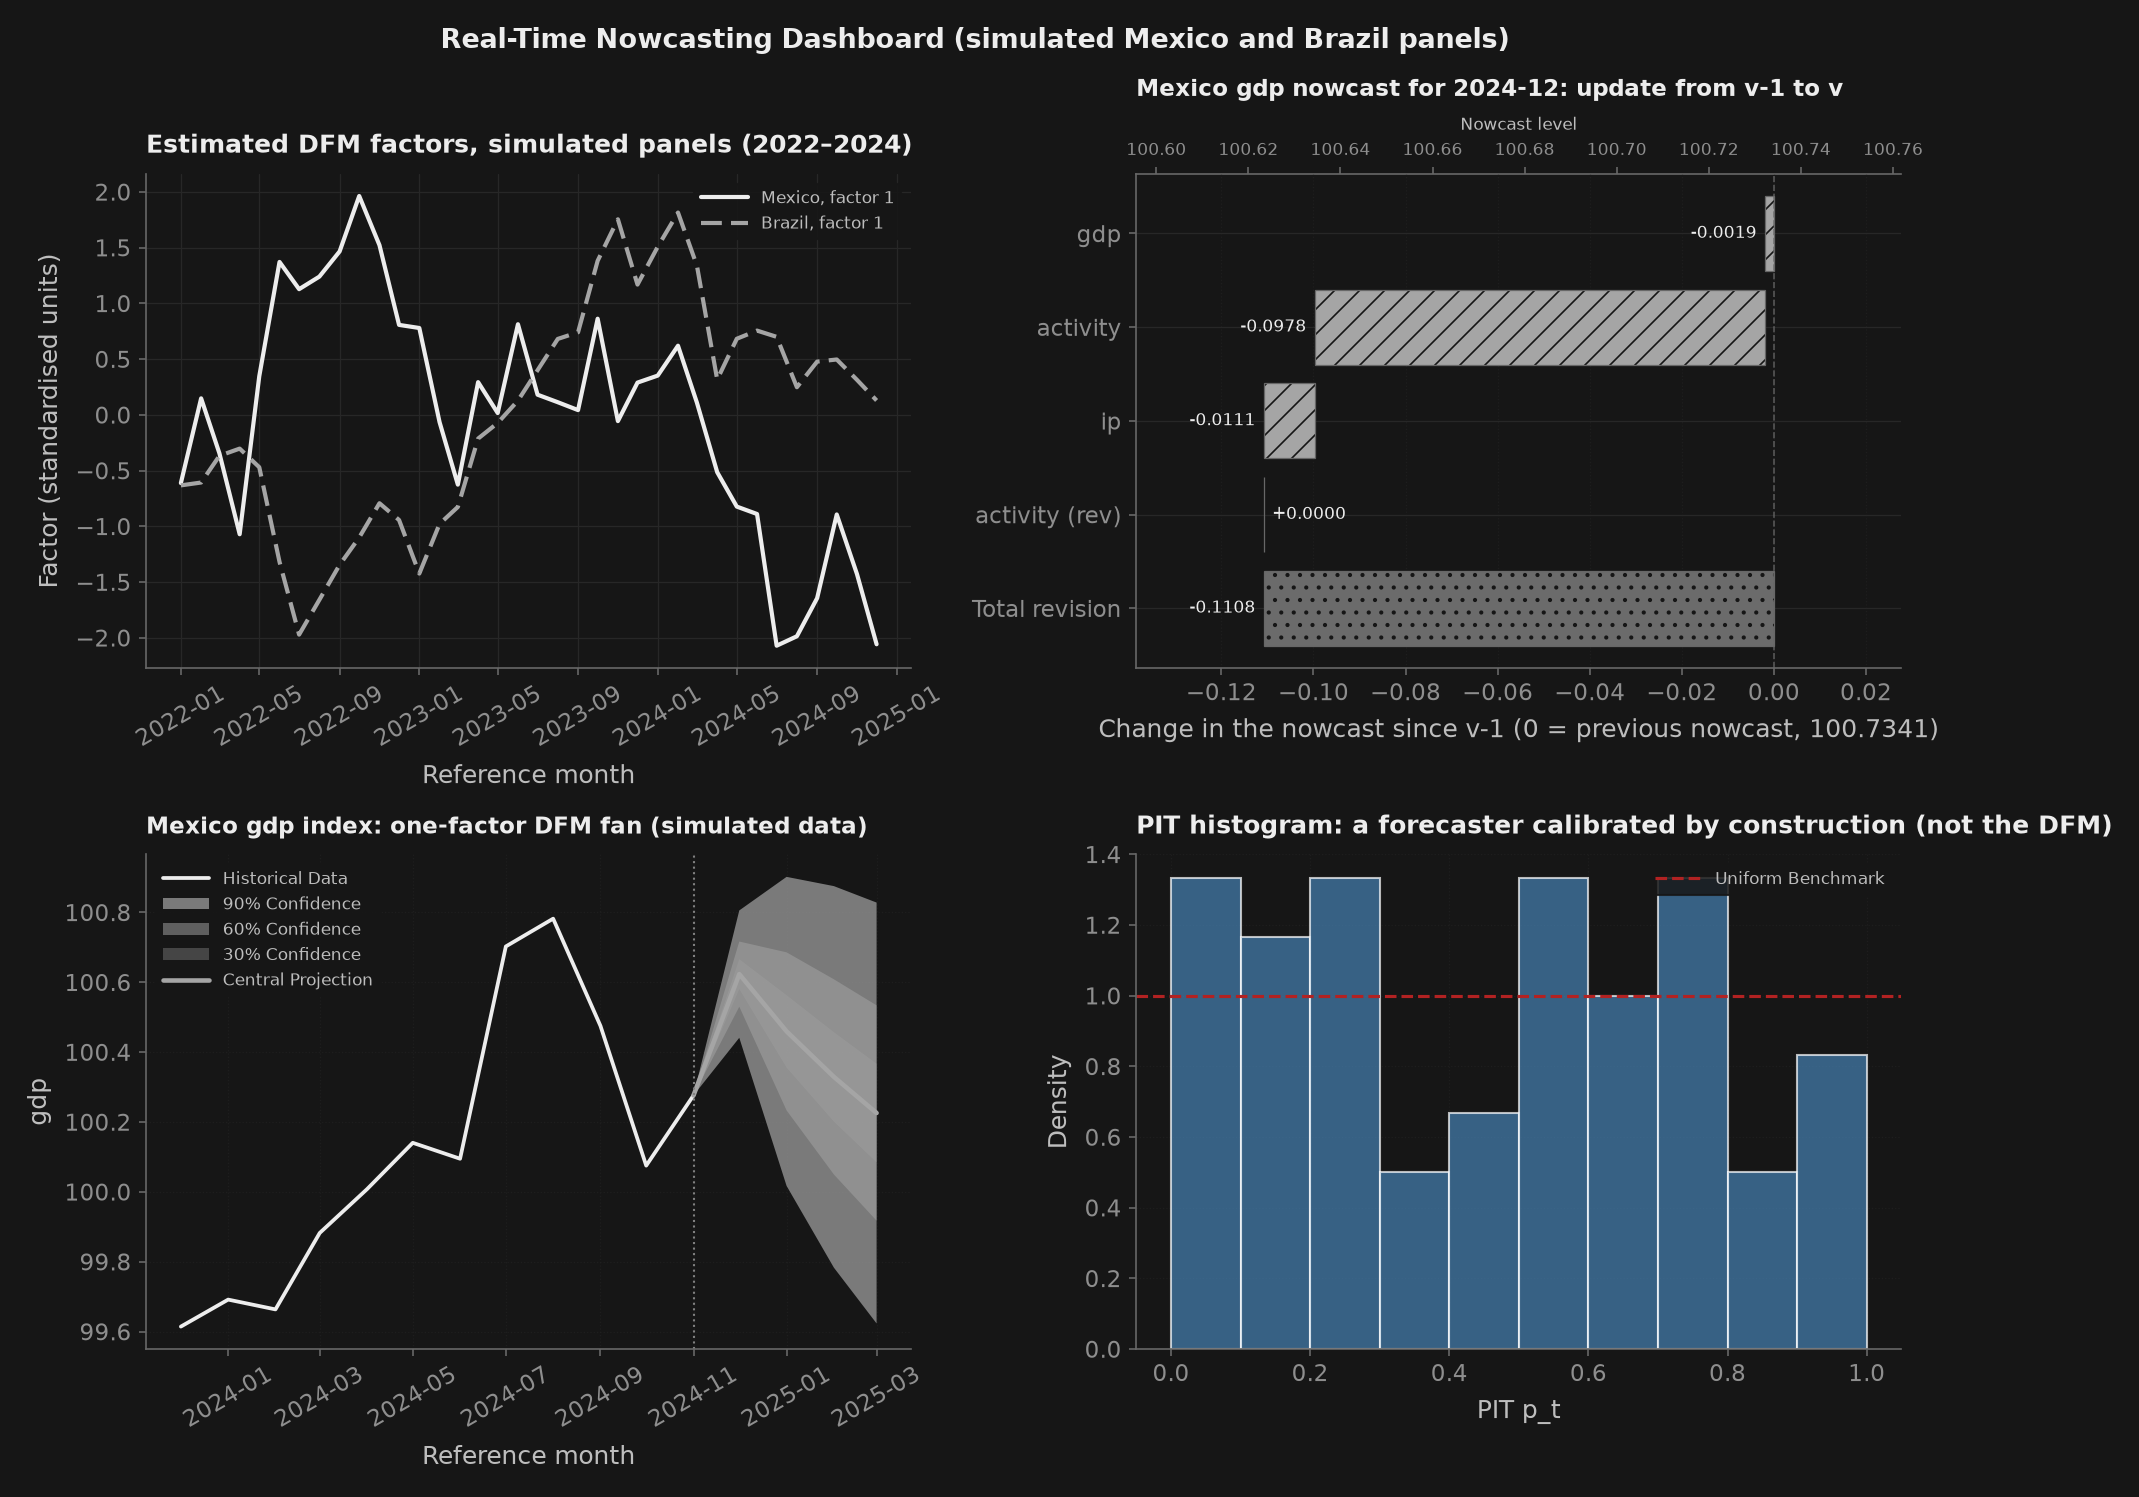

In [5]:
# --- Dashboard: factors, news attribution, fan chart and PIT histogram ---
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

ax = axes[0, 0]
ax.plot(res_mex.factors.index, res_mex.factors.iloc[:, 0], **_nbstyle.S1, label="Mexico, factor 1")
ax.plot(res_bra.factors.index, res_bra.factors.iloc[:, 0], **_nbstyle.S2, label="Brazil, factor 1")
ax.set_title("Estimated DFM factors, simulated panels (2022–2024)")
ax.set_xlabel("Reference month")
ax.set_ylabel("Factor (standardised units)")
ax.tick_params(axis="x", labelrotation=30)
ax.legend(loc="best", fontsize=8)

# News attribution: the library's waterfall, drawn relative to the previous nowcast
nd_mex.plot(ax=axes[0, 1], title=f"Mexico gdp nowcast for {target_month:%Y-%m}: update from v-1 to v")

# Fan chart: published gdp, then the DFM's own predictive bands (same as fc_mex above)
res_mex.plot_fan_chart(ax=axes[1, 0], horizon=3, palette=_nbstyle.S2["color"],
                       title="Mexico gdp index: one-factor DFM fan (simulated data)")
axes[1, 0].set_xlabel("Reference month")
axes[1, 0].tick_params(axis="x", labelrotation=30)

pit_res.plot(ax=axes[1, 1], title="PIT histogram: a forecaster calibrated by construction (not the DFM)")

fig.suptitle("Real-Time Nowcasting Dashboard (simulated Mexico and Brazil panels)")
fig.tight_layout()

## Lectura de los resultados

**Lectura de los resultados.** Todos los datos son simulados, así que los números ilustran el método, no a México ni a Brasil.

1. **El borde irregular.** El 2025-01-15 el índice simulado `gdp` está publicado hasta 2024-10, `activity` e `ip` hasta 2024-11, y `cpi` y la tasa de política hasta 2024-12. Un mes después cada serie rezagada gana un mes, y se revisa `activity` de 2023-09. El objetivo, `gdp` de 2024-12, no está publicado en ninguna de las dos ediciones, así que el nowcast es la estimación del modelo y no una cifra publicada.
2. **El nowcast y su actualización.** El 2025-02-15 el DFM de un factor estima el índice en $100.6233$ con una desviación estándar de $0.1108$ (intervalo de 90% $[100.4411, 100.8056]$). Con los parámetros fijos en sus estimaciones actuales, el nowcast de la edición anterior era $100.7341$, así que se movió $-0.1108$. La publicación de `activity` de diciembre explica casi todo el movimiento: salió $0.2693$ por debajo de lo que esperaba el modelo y, con una ponderación de $0.3633$, redujo el nowcast en $0.0978$. La publicación de `ip` restó otros $0.0111$, y la de `gdp` de noviembre solo $0.0019$ (ponderación $0.0130$), porque para entonces `activity` e `ip` ya le habían informado al modelo sobre los últimos meses. La revisión de $0.45$ a `activity` de 2023-09 recibe una ponderación que se redondea a $0.0000$: los quince meses posteriores están observados, así que casi no aporta información sobre diciembre. El error de descomposición de $1.05 \times 10^{-15}$ confirma la identidad contable, una verificación interna. La cascada de la figura (`NewsDecompositionResult.plot`) dibuja los mismos impactos, sumados por serie, como cambios respecto del nowcast anterior.
3. **Reproducir el pasado.** Consultado `as_of` 2025-01-15, `realtime_nowcast` devuelve $100.7200$ con una desviación estándar de $0.1471$ y sin descomposición de noticias, pues no existe una edición anterior; la misma llamada sobre un panel que simplemente termina en esa fecha da el mismo número, así que la reproducción usó solo datos publicados hasta entonces. Eso difiere del "nowcast anterior" de la descomposición en $+0.0142$, el efecto de reestimar los parámetros con la edición posterior. El mes adicional de datos estrechó la banda de $0.1471$ a $0.1108$.
4. **Brasil.** Su nowcast es $99.3438$ (desviación estándar $0.1757$) y se movió $-0.0173$ entre las ediciones, de nuevo con una descomposición exacta ($6.0 \times 10^{-15}$). El factor de Brasil se simula de forma independiente del de México, así que las dos trayectorias de factores del primer panel no están relacionadas por construcción.
5. **El gráfico de abanico.** `res_mex.fan_chart` construye el abanico con las propias matrices de espacio de estados del DFM, y un cálculo aparte de la fórmula de la sección 3 da los mismos números: su desviación estándar es $0.1108$ para el nowcast de diciembre y crece a $0.2689$, $0.3320$ y $0.3662$ de enero a marzo de 2025. La trayectoria central baja de $100.6233$ a $100.2257$ porque el factor del modelo es una autorregresión estacionaria, así que sus pronósticos regresan hacia la media muestral, mientras que el factor simulado es una caminata aleatoria. Las bandas ignoran la incertidumbre de los parámetros y esta mala especificación, y los colores son solo estilo; nada aquí es una proyección oficial.
6. **Las pruebas PIT.** Los 60 pronósticos del Experimento 3a no son los del DFM: son correctos por construcción. Las pruebas no rechazan (Berkowitz $LR = 2.8021$, $p = 0.4232$; KS $= 0.1015$, $p = 0.5327$), como no deben hacerlo en cerca del 95% de tales muestras. El resumen lo reporta como un no rechazo, no como prueba de calibración, y no dice nada sobre los nowcasts de arriba. La celda de Tu turno mide con qué frecuencia las pruebas detectan a un pronosticador mal calibrado.

## Tu turno

El Experimento 3a corrió las pruebas PIT una sola vez, sobre un pronosticador correcto por construcción, así que solo podía mostrar que las pruebas no rechazan cuando no deben, y aun eso una sola vez. ¿Con qué frecuencia detectan a un pronosticador cuyas bandas son demasiado estrechas o demasiado anchas? La celda de abajo extrae 500 muestras de 60 pronósticos, como en el Experimento 3a, para un pronosticador calibrado y para uno que reporta `sigma_scale` veces la desviación estándar verdadera, y cuenta con qué frecuencia rechaza cada prueba al 5%.

**Prediga primero:** frente a una varianza del pronóstico equivocada, ¿qué prueba rechaza más a menudo, la LR de Berkowitz o la KS? Piense en qué le hace una densidad demasiado estrecha al histograma de las PIT y a su distribución acumulada. Las verificaciones confirman que ambas pruebas tienen aproximadamente el tamaño correcto, que la prueba LR detecta a su pronosticador, y su predicción.

In [6]:
# Your turn: size and power of the PIT tests by Monte Carlo
sigma_scale = 0.6   # ← change this: forecast s.d. over the true s.d., 0.5 to 0.8 (too narrow) or 1.25 to 2.0 (too wide)
assert 0.5 <= sigma_scale <= 0.8 or 1.25 <= sigma_scale <= 2.0
R_mc, T_mc = 500, 60

def rejection_rates(scale, bias=0.0, phi=0.0, R=R_mc, T=T_mc):
    """Share of R samples in which the Berkowitz LR and the KS tests reject at 5%.

    The outcome is y = mu + bias * sd + sd * e, where e has unit variance and is an AR(1) with
    coefficient phi. The forecaster reports N(mu, (scale * sd)^2). Each replication has its own seed.
    """
    lr = ks = 0
    for s in range(R):
        g = np.random.default_rng(s)
        mu = g.normal(2.0, 0.5, T)
        sd = g.uniform(0.4, 0.8, T)
        u = g.normal(size=T)
        e = u.copy()
        for t in range(1, T):
            e[t] = phi * e[t - 1] + np.sqrt(1.0 - phi**2) * u[t]
        y = mu + bias * sd + sd * e
        test = pit_uniformity_test(realised=y, mu=mu, sigma=scale * sd)
        lr += test.lr_pvalue < 0.05
        ks += test.ks_pvalue < 0.05
    return lr / R, ks / R

size_lr, size_ks = rejection_rates(1.0)
power_lr, power_ks = rejection_rates(sigma_scale)
mc_se = np.sqrt(0.05 * 0.95 / R_mc)
print(f"Calibrated forecaster (size): LR {size_lr:.3f}, KS {size_ks:.3f} (nominal 0.05, Monte Carlo s.e. {mc_se:.3f})")
print(f"Forecast s.d. x {sigma_scale} (power): LR {power_lr:.3f}, KS {power_ks:.3f}")

assert abs(size_lr - 0.05) < 4 * mc_se and abs(size_ks - 0.05) < 4 * mc_se, "a test's size is far from 5%"
assert power_lr > size_lr + 4 * mc_se, "the LR test should detect this forecaster"
assert power_lr > power_ks, "your prediction: the LR test is more powerful against a wrong variance"

Calibrated forecaster (size): LR 0.070, KS 0.066 (nominal 0.05, Monte Carlo s.e. 0.010)
Forecast s.d. x 0.6 (power): LR 1.000, KS 0.638


**Indicaciones.**
1. *Básico.* Mueva `sigma_scale` de $0.8$ a $0.5$ y de $1.25$ a $2.0$. ¿Qué tan rápido crece la potencia de cada prueba? Compare $0.8$ con su recíproco $1.25$: ¿qué error es más fácil de detectar con 60 pronósticos, y por qué?
2. *Intermedio.* Ahora deje la varianza correcta y desplace el resultado: compare `rejection_rates(1.0, bias=0.25)` con `rejection_rates(1.0, bias=0.5)`. ¿Qué prueba gana frente a un pronosticador sesgado, y qué parámetro de Berkowitz ($\mu$, $\sigma_\varepsilon$, $\rho$) mueve el sesgo? Autoverificación: `assert min(rejection_rates(1.0, bias=0.5)) > 0.85`.
3. *Avanzado.* Mantenga cada PIT marginalmente uniforme pero haga que los errores del pronóstico estén correlacionados en el tiempo: `lr, ks = rejection_rates(1.0, phi=0.5)`. ¿Qué prueba lo nota, y por qué la KS rechaza más del 5% aunque cada $p_t$ sea $\mathcal{U}(0,1)$? Autoverificación: `assert lr > 0.8 and lr - ks > 0.3`. Para calificar al propio DFM habría que reproducirlo con `as_of` sobre muchas ediciones y aplicar las mismas pruebas a sus PIT.

## ¿Qué tan exhaustivo es esto?

- `puremacro.fetch.realtime`: paneles de ediciones y conectores para Banxico, INEGI, BCB y BCCh (`VintagePanel`, `pack_realtime_cartridge`, `load_realtime_cartridge`); los conectores descargan datos y no se llaman aquí.
- `puremacro.nowcast.realtime_nowcast`: el orquestador usado arriba, con `as_of` y `previous_vintage` para reproducciones históricas y `method="mfvar"` para un VAR de frecuencia mixta; los métodos `fan_chart` y `plot_fan_chart` de su resultado dibujan el abanico predictivo del DFM después de los datos publicados (rechazan un resultado `mfvar`, que no tiene varianzas predictivas).
- `puremacro.nowcast.dfm` y `puremacro.nowcast.news`: el modelo de factores dinámicos (`DynamicFactorModel`) y la descomposición de noticias (`banbura_modugno_news`, `NewsDecompositionResult` y su cascada `plot`).
- `puremacro.nowcast.evaluation`: `fan_chart`, `pit_uniformity_test`, `crps_gaussian` y `log_score_gaussian` para pronósticos de densidad.
- El cuaderno 58 construye paneles de ediciones en tiempo real para América Latina; el cuaderno 48 hace nowcasting con un objetivo reservado; el cuaderno 38 prueba si las revisiones son noticia o ruido.